<a href="https://colab.research.google.com/github/nds-najam/Chronos_Model_Comparison/blob/main/notebooks/AutoGluon_Electricity_Weather_NASA_Ahmedabad_Dataset_Forecast_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# We use uv for faster installation
!pip install uv
!uv pip install -q autogluon.timeseries --system
!uv pip uninstall -q torchaudio torchvision torchtext --system # fix incompatible package versions on Colab

### Preparing the data for AutoGluon

In [2]:
import pandas as pd

url = csv = "https://drive.google.com/uc?export=download&id=1OvFNVhJ-vNSeUpJhD2MCntbaXNbUrr_R"
df = pd.read_csv(url)
df.head()

,YEAR,Month,Day,Hour,irradiance,temperature,dewpoint,specific humidity,wind speed,Electric Load (MW)
0,2021,11,1,5,0.00,15.39,13.23,9.46,2.33,46.9493
1,2021,11,1,6,4.40,15.10,13.25,9.46,2.38,50.2240
2,2021,11,1,7,196.46,17.47,13.55,9.64,3.36,58.3981
3,2021,11,1,8,381.62,20.04,14.01,9.95,2.73,56.3945
4,2021,11,1,9,528.48,24.10,14.38,10.19,1.58,57.8824


In [3]:
df['timestamp'] = pd.to_datetime(df[['YEAR', 'Month', 'Day', 'Hour']])
df.head()

,YEAR,Month,Day,Hour,irradiance,temperature,dewpoint,specific humidity,wind speed,Electric Load (MW),timestamp
0,2021,11,1,5,0.00,15.39,13.23,9.46,2.33,46.9493,2021-11-01 05:00:00
1,2021,11,1,6,4.40,15.10,13.25,9.46,2.38,50.2240,2021-11-01 06:00:00
2,2021,11,1,7,196.46,17.47,13.55,9.64,3.36,58.3981,2021-11-01 07:00:00
3,2021,11,1,8,381.62,20.04,14.01,9.95,2.73,56.3945,2021-11-01 08:00:00
4,2021,11,1,9,528.48,24.10,14.38,10.19,1.58,57.8824,2021-11-01 09:00:00


In [5]:
df['timestamp'] = pd.to_datetime(df[['YEAR', 'Month', 'Day', 'Hour']])
df["item_id"] = "Electricity-Weather-NASA"
# data = data[["item_id", "timestamp", "irradiance","temperature",
#              "dewpoint", "specific humidity","wind speed","Electric Load (MW)"]]
df = df.rename(columns={"Electric Load (MW)": "Load"})
# df["item_id"] = "Electricity-Weather-NASA"
df = df[["item_id", "timestamp", "Load"]]
df = df.rename(columns={"Load": "target"})
df.head()

,item_id,timestamp,target
0,Electricity-Weather-NASA,2021-11-01 05:00:00,46.9493
1,Electricity-Weather-NASA,2021-11-01 06:00:00,50.2240
2,Electricity-Weather-NASA,2021-11-01 07:00:00,58.3981
3,Electricity-Weather-NASA,2021-11-01 08:00:00,56.3945
4,Electricity-Weather-NASA,2021-11-01 09:00:00,57.8824


### Import the libraries

In [6]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [7]:
from autogluon.timeseries import TimeSeriesDataFrame

data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp",
)

data.head()

target
item_id                  timestamp                   
Electricity-Weather-NASA 2021-11-01 05:00:00  46.9493
                         2021-11-01 06:00:00  50.2240
                         2021-11-01 07:00:00  58.3981
                         2021-11-01 08:00:00  56.3945
                         2021-11-01 09:00:00  57.8824

### Zero Shot Inferencing

We are comparing three models:
- Chronos2
- Chronos-bolt
- Chronos-T5

In [8]:
from autogluon.timeseries import TimeSeriesPredictor

num_test_windows = 3
prediction_length = 48

train_data, test_data = data.train_test_split(
    num_test_windows * prediction_length
)

predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="target",
    eval_metric="MASE",
).fit(
    train_data=train_data,
    hyperparameters={
        # Chronos-2 (Zero-shot)
        "Chronos2": [
            {
                "ag_args": {
                    "name_suffix": "ZeroShot",
                }
            }
        ],

        # Original Chronos models
        "Chronos": [
            {
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small",
                },
            },
            {
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall",
                },
            },
        ],
    },
    enable_ensemble=False,
    time_limit=300,
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/content/AutogluonModels/ag-20260812_050402'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       11.48 GB / 12.67 GB (90.6%)
Disk Space Avail:   187.24 GB / 235.68 GB (79.4%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small'},
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suffix': 'BoltSmall'},
                                  'model_pat

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-0.4047       = Validation score (-MASE)
	5.66    s     = Training runtime
	1.09    s     = Validation (prediction) runtime
Training timeseries model ChronosT5Small[autogluon__chronos-t5-small]. Training for up to 145.7s of the 291.3s of remaining time.


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

	-0.4091       = Validation score (-MASE)
	0.39    s     = Training runtime
	1.59    s     = Validation (prediction) runtime
Training timeseries model ChronosBoltSmall[autogluon__chronos-bolt-small]. Training for up to 289.3s of the 289.3s of remaining time.


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

	-0.4927       = Validation score (-MASE)
	0.02    s     = Training runtime
	0.79    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2ZeroShot', 'ChronosT5Small[autogluon__chronos-t5-small]', 'ChronosBoltSmall[autogluon__chronos-bolt-small]']
Total runtime: 9.57 s
Best model: Chronos2ZeroShot
Best model score: -0.4047


In [9]:
predictions = predictor.predict(train_data)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: Chronos2ZeroShot


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

mean        0.1        0.2  \
item_id                  timestamp                                              
Electricity-Weather-NASA 2022-10-27 00:00:00  41.080128  38.822670  39.583420   
                         2022-10-27 01:00:00  39.403343  36.346169  37.531853   
                         2022-10-27 02:00:00  37.746983  34.498051  35.741074   
                         2022-10-27 03:00:00  36.804661  33.656574  34.906631   
                         2022-10-27 04:00:00  37.099861  33.650986  34.951252   

                                                    0.3        0.4        0.5  \
item_id                  timestamp                                              
Electricity-Weather-NASA 2022-10-27 00:00:00  40.232170  40.477306  41.080128   
                         2022-10-27 01:00:00  38.411713  38.785019  39.403343   
                         2022-10-27 02:00:00  36.404190  36.999397  37.746983   
                         2022-10-27 03:00:00  35.653450  36.327847  36.804661   
                         2022-10-27 04:00:00  36.003349  36.678658  37.099861   

                                                    0.6        0.7        0.8  \
item_id                  timestamp                                              
Electricity-Weather-NASA 2022-10-27 00:00:00  41.290676  41.724865  41.874489   
                         2022-10-27 01:00:00  39.672821  40.110653  40.819412   
                         2022-10-27 02:00:00  38.100746  38.697475  39.574566   
                         2022-10-27 03:00:00  37.731659  38.223385  39.249043   
                         2022-10-27 04:00:00  37.664085  38.378365  39.624622   

                                                    0.9  
item_id                  timestamp                       
Electricity-Weather-NASA 2022-10-27 00:00:00  42.759415  
                         2022-10-27 01:00:00  41.911724  
                         2022-10-27 02:00:00  40.636570  
                         2022-10-27 03:00:00  40.669537  
                         2022-10-27 04:00:00  41.190830

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

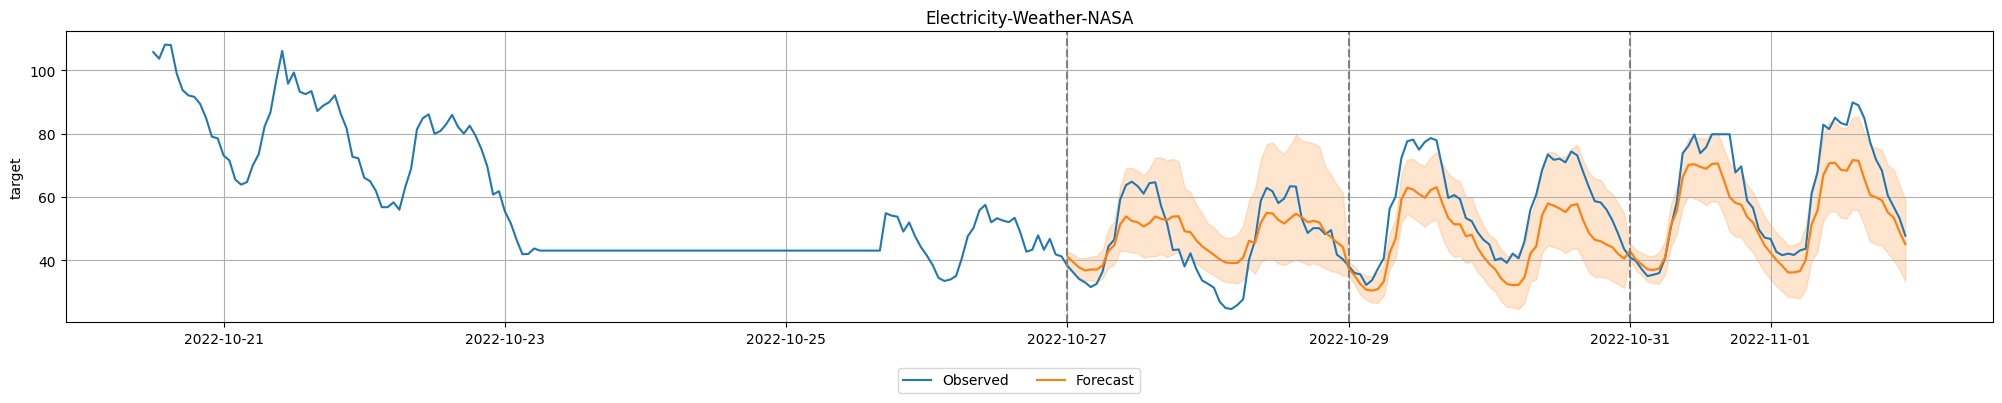

In [10]:
import matplotlib.pyplot as plt

# Generate predictions for multiple windows
predictions_per_window = predictor.backtest_predictions(test_data, num_val_windows=num_test_windows)

# Plot predictions for the first two time series
item_ids = test_data.item_ids[:2].tolist()
all_predictions = pd.concat(predictions_per_window)
predictor.plot(test_data, all_predictions, max_history_length=300, item_ids=item_ids)

# Optional: Plot the cutoff dates with dashed vertical lines
for cutoff in range(-num_test_windows * prediction_length, 0, prediction_length):
    for i, ax in enumerate(plt.gcf().axes):
        cutoff_timestamp = test_data.loc[item_ids[i]].index[cutoff]
        ax.axvline(cutoff_timestamp, color='gray', linestyle='--')
plt.show()

In [11]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,ChronosT5Small[autogluon__chronos-t5-small],-0.611273,-0.409058,1.389565,1.585808,0.392821,2
1,Chronos2ZeroShot,-0.742672,-0.404688,0.847085,1.089852,5.656306,1
2,ChronosBoltSmall[autogluon__chronos-bolt-small],-0.773350,-0.492714,0.709830,0.793643,0.016728,3


## Forecasting with covariates

In [12]:
# data = TimeSeriesDataFrame.from_path(
#     "https://drive.google.com/uc?export=download&id=1OvFNVhJ-vNSeUpJhD2MCntbaXNbUrr_R"
# )
data = pd.read_csv(
    "https://drive.google.com/uc?export=download&id=1OvFNVhJ-vNSeUpJhD2MCntbaXNbUrr_R"
)
data['timestamp'] = pd.to_datetime(data[['YEAR', 'Month', 'Day', 'Hour']])
data["item_id"] = "Electricity-Weather-NASA"
data = data[["item_id", "timestamp", "irradiance","temperature",
             "dewpoint", "specific humidity","wind speed","Electric Load (MW)"]]
data = data.rename(columns={"Electric Load (MW)": "Load"})

data = TimeSeriesDataFrame.from_data_frame(
    data,
    id_column="item_id",
    timestamp_column="timestamp")
data.head()


irradiance  temperature  \
item_id                  timestamp                                      
Electricity-Weather-NASA 2021-11-01 05:00:00        0.00        15.39   
                         2021-11-01 06:00:00        4.40        15.10   
                         2021-11-01 07:00:00      196.46        17.47   
                         2021-11-01 08:00:00      381.62        20.04   
                         2021-11-01 09:00:00      528.48        24.10   

                                              dewpoint  specific humidity  \
item_id                  timestamp                                          
Electricity-Weather-NASA 2021-11-01 05:00:00     13.23               9.46   
                         2021-11-01 06:00:00     13.25               9.46   
                         2021-11-01 07:00:00     13.55               9.64   
                         2021-11-01 08:00:00     14.01               9.95   
                         2021-11-01 09:00:00     14.38              10.19   

                                              wind speed     Load  
item_id                  timestamp                                 
Electricity-Weather-NASA 2021-11-01 05:00:00        2.33  46.9493  
                         2021-11-01 06:00:00        2.38  50.2240  
                         2021-11-01 07:00:00        3.36  58.3981  
                         2021-11-01 08:00:00        2.73  56.3945  
                         2021-11-01 09:00:00        1.58  57.8824

In [13]:
prediction_length = 48
train_data, test_data = data.train_test_split(prediction_length=prediction_length)

In [14]:
!uv pip install -q -U "torchao>=0.16.0"

In [15]:
predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="Load",
    known_covariates_names=["irradiance","temperature",
             "dewpoint", "specific humidity","wind speed"],
    eval_metric="MASE",
).fit(
    train_data,
    hyperparameters={
        # Chronos-2 (Zero-shot)
        "Chronos2": [
            {
                "ag_args": {
                    "name_suffix": "ZeroShot",
                }
            }
        ],

        # Original Chronos models
        "Chronos": [
            {
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small",
                },
            },
            {
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall",
                },
            },
        ],
    },
    enable_ensemble=False,
    time_limit=300,
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/content/AutogluonModels/ag-20260812_050550'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.01 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.35 GB / 12.67 GB (81.7%)
Disk Space Avail:   187.22 GB / 235.68 GB (79.4%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small'},
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suffix': 'BoltSmall'},
                                  'model_pat

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-1.1190       = Validation score (-MASE)
	0.84    s     = Training runtime
	0.31    s     = Validation (prediction) runtime
Training timeseries model ChronosT5Small[autogluon__chronos-t5-small]. Training for up to 149.4s of the 298.8s of remaining time.


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

	-1.0154       = Validation score (-MASE)
	0.02    s     = Training runtime
	1.25    s     = Validation (prediction) runtime
Training timeseries model ChronosBoltSmall[autogluon__chronos-bolt-small]. Training for up to 297.5s of the 297.5s of remaining time.


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

	-1.0340       = Validation score (-MASE)
	0.02    s     = Training runtime
	0.83    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2ZeroShot', 'ChronosT5Small[autogluon__chronos-t5-small]', 'ChronosBoltSmall[autogluon__chronos-bolt-small]']
Total runtime: 3.30 s
Best model: ChronosT5Small[autogluon__chronos-t5-small]
Best model score: -1.0154


In [16]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,ChronosT5Small[autogluon__chronos-t5-small],-0.735173,-1.015384,1.360368,1.246046,0.018286,2
1,ChronosBoltSmall[autogluon__chronos-bolt-small],-0.773350,-1.034003,0.747512,0.833569,0.017060,3
2,Chronos2ZeroShot,-0.780458,-1.118970,1.051236,0.312173,0.842537,1


In [18]:
predictor.feature_importance(test_data, model="Chronos2ZeroShot", relative_scores=True)

Computing feature importance


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

,importance,stdev,n,p99_low,p99_high
dewpoint,0.066520,0.000000e+00,5.0,0.066520,0.066520
specific humidity,0.053462,7.757919e-18,5.0,0.053462,0.053462
temperature,-0.028556,3.878960e-18,5.0,-0.028556,-0.028556
irradiance,-0.031268,0.000000e+00,5.0,-0.031268,-0.031268
wind speed,-0.069829,0.000000e+00,5.0,-0.069829,-0.069829


## Fine Tuning the Model

In [19]:
predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="Load",
    known_covariates_names=["irradiance","temperature",
             "dewpoint", "specific humidity","wind speed"],
    eval_metric="MASE",
).fit(
    train_data=train_data,
    hyperparameters={
        "Chronos2": [
            # Zero-shot model
            {"fine_tune": False,
             "ag_args": {"name_suffix": "ZeroShot"}},
            # Fine-tuned model
            {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}},
        ],

        # Original Chronos models
        "Chronos": [
            {
                "fine_tune":False,
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small_ZeroShot",
                },
            },
            {
                "fine_tune":False,
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall_ZeroShot",
                },
            },
            {
                "fine_tune":True,
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small_finetune",
                },
            },
            {
                "fine_tune":True,
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall_finetune",
                },
            },
        ],
    },
    time_limit=600,  # time limit in seconds
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/content/AutogluonModels/ag-20260812_050730'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.01 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.32 GB / 12.67 GB (81.4%)
Disk Space Avail:   187.22 GB / 235.68 GB (79.4%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small_ZeroShot'},
                                  'fine_tune': False,
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suff

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-1.1190       = Validation score (-MASE)
	0.83    s     = Training runtime
	0.34    s     = Validation (prediction) runtime
Training timeseries model Chronos2FineTuned. Training for up to 119.8s of the 598.8s of remaining time.


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.
	-1.0383       = Validation score (-MASE)
	112.38  s     = Training runtime
	0.53    s     = Validation (prediction) runtime
Training timeseries model ChronosT5Small_ZeroShot[autogluon__chronos-t5-small]. Training for up to 121.5s of the 485.9s of remaining time.


...

	-1.0848       = Validation score (-MASE)
	195.28  s     = Training runtime
	0.53    s     = Validation (prediction) runtime
Training timeseries model ChronosBoltSmall_finetune[autogluon__chronos-bolt-small]. Training for up to 288.0s of the 288.0s of remaining time.


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

	Saving fine-tuned model to /content/AutogluonModels/ag-20260812_050730/models/ChronosBoltSmall_finetune[autogluon__chronos-bolt-small]/W0/fine-tuned-ckpt


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

	-0.5884       = Validation score (-MASE)
	232.11  s     = Training runtime
	0.04    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2ZeroShot', 'Chronos2FineTuned', 'ChronosT5Small_ZeroShot[autogluon__chronos-t5-small]', 'ChronosBoltSmall_ZeroShot[autogluon__chronos-bolt-small]', 'ChronosT5Small_finetune[autogluon__chronos-t5-small]', 'ChronosBoltSmall_finetune[autogluon__chronos-bolt-small]']
Total runtime: 544.17 s
Best model: ChronosBoltSmall_finetune[autogluon__chronos-bolt-small]
Best model score: -0.5884


In [20]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,ChronosBoltSmall_finetune[autogluon__chronos-b...,-0.359565,-0.588374,0.206040,0.042214,232.106773,6
1,ChronosT5Small_ZeroShot[autogluon__chronos-t5-...,-0.732130,-0.813070,1.307239,1.263510,0.018106,3
2,Chronos2FineTuned,-0.767118,-1.038288,1.293723,0.534656,112.381024,2
3,ChronosBoltSmall_ZeroShot[autogluon__chronos-b...,-0.773350,-1.034003,0.723570,0.764335,0.021845,4
4,Chronos2ZeroShot,-0.780458,-1.118970,1.107736,0.340831,0.834123,1
5,ChronosT5Small_finetune[autogluon__chronos-t5-...,-0.948804,-1.084830,0.715695,0.525431,195.282768,5
